<a href="https://colab.research.google.com/github/SohamBhattacharjee2003/Machine_Learing_Algorithms/blob/main/Ridge_and_Lasco_Regretion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Ridge Regression**

In [1]:
from sklearn.datasets import fetch_california_housing

In [5]:
import numpy as np
import pandas as pd

In [6]:
df = fetch_california_housing()

In [7]:
dataset = pd.DataFrame(df.data)

In [8]:
dataset.columns = df.feature_names

In [9]:
## Independent and Dependent Feature
x = dataset
y = df.target

In [12]:
## Train and Split
from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.30,random_state=4)

In [10]:
from sklearn.preprocessing import StandardScaler
scalar = StandardScaler()

In [13]:
x_train = scalar.fit_transform(x_train)
scalar.inverse_transform(x_train)

array([[   2.1473    ,   41.        ,    3.41618497, ...,    4.75144509,
          33.97      , -118.24      ],
       [   3.525     ,   34.        ,    4.2962963 , ...,    2.45679012,
          37.63      , -122.49      ],
       [   1.5491    ,   20.        ,    1.64      , ...,    3.48      ,
          34.06      , -118.25      ],
       ...,
       [   2.7969    ,   38.        ,    4.06701031, ...,    2.26546392,
          37.48      , -122.23      ],
       [   2.6734    ,   26.        ,    4.23893805, ...,    2.58849558,
          33.97      , -118.35      ],
       [   2.5673    ,   48.        ,    3.68396226, ...,    3.46462264,
          37.35      , -121.89      ]])

In [14]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

In [15]:
ridge_regressor = Ridge()

In [16]:
parameters = {'alpha' : [1,2,5,10,20,30,40,50,60,70,80,90]}
ridgecv = GridSearchCV(ridge_regressor,parameters,scoring = 'neg_mean_squared_error',cv=5)

In [17]:
ridgecv.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=Ridge(),
             param_grid={'alpha': [1, 2, 5, 10, 20, 30, 40, 50, 60, 70, 80,
                                   90]},
             scoring='neg_mean_squared_error')

In [19]:
print(ridgecv.best_params_)

{'alpha': 40}


In [20]:
print(ridgecv.best_score_)

-0.5325184379058617


In [21]:
ridge_pred = ridgecv.predict(x_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but Ridge was fitted without feature names
  warnings.warn(


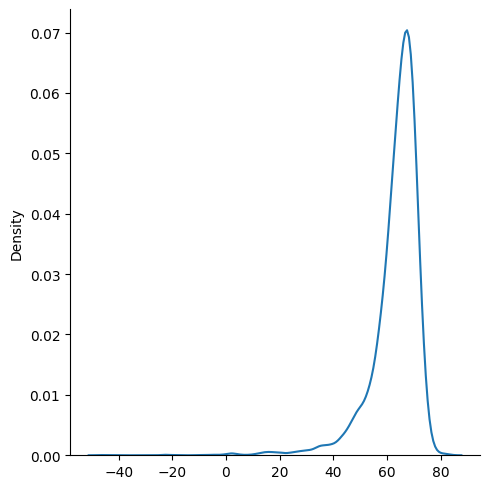

In [22]:
import seaborn as sns
sns.displot(ridge_pred-y_test,kind='kde')

# **Lasso Regression**

In [23]:
from sklearn.linear_model import Lasso

In [24]:
lasso = Lasso()

In [28]:
parameters = {'alpha' : [1,2,5,10,20,30,40,50,60,70,80,90]}
lassocv = GridSearchCV(lasso,parameters,scoring = 'neg_mean_squared_error',cv=5)
lassocv.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=Lasso(),
             param_grid={'alpha': [1, 2, 5, 10, 20, 30, 40, 50, 60, 70, 80,
                                   90]},
             scoring='neg_mean_squared_error')

In [29]:
print(lassocv.best_params_)
print(lassocv.best_score_)

{'alpha': 1}
-1.3421628356189998


In [30]:
lasso_pred = lassocv.predict(x_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but Lasso was fitted without feature names
  warnings.warn(


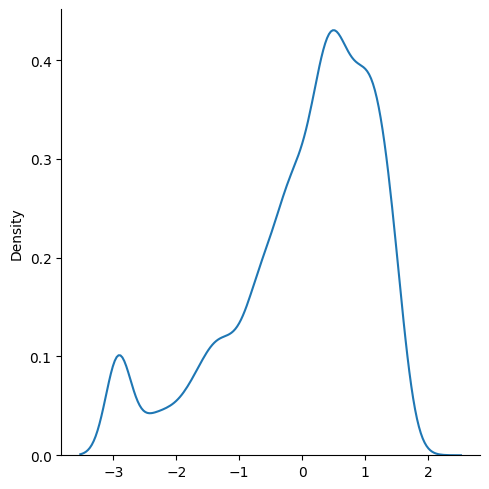

In [31]:
import seaborn as sns
sns.displot(lasso_pred-y_test,kind='kde')